<a href="https://colab.research.google.com/github/ElofssonLab/kb8029-book/blob/main/notebooks/day01-math-in-code.ipynb" style="display:inline-block;padding:10px 18px;background-color:#F9AB00;color:#000000;font-weight:bold;text-decoration:none;border-radius:6px;font-family:sans-serif;font-size:14px;">&#9654;&nbsp; Open in Google Colab</a>

# Day 1 — Math in code {.unnumbered}

This notebook recomputes every worked example and practice problem from the Day 1 page, in code, so you can confirm code and by-hand math agree. No new ideas here — Day 2 is where the code side of this course actually starts.

In [1]:
import torch
import warnings
warnings.filterwarnings('ignore')
import numpy as np
torch.manual_seed(0)

## Length, absolute value, and size

In [2]:
v = torch.tensor([3., 4.])
print("||v|| =", torch.linalg.vector_norm(v).item())

# Practice problem 1a: length of (1, 2, 2)
v1 = torch.tensor([1., 2., 2.])
print("practice problem 1a:", torch.linalg.vector_norm(v1).item())

# Practice problem 1b: Frobenius norm of the 2x2 identity matrix
I = torch.eye(2)
print("practice problem 1b:", torch.linalg.matrix_norm(I, ord="fro").item())


||v|| = 5.0
practice problem 1a: 3.0
practice problem 1b: 1.4142135381698608


## Dot product

In [3]:
w = torch.tensor([2., -1.])
x = torch.tensor([1., 4.])
print("w . x =", torch.dot(w, x).item())

# Practice problem 1
a = torch.tensor([2., -1., 3.])
b = torch.tensor([1., 4., 0.])
print("practice problem 1:", torch.dot(a, b).item())

w . x = -2.0
practice problem 1: -2.0


## Normalization

In [4]:
w = torch.tensor([2., -1.])
w_hat = w / torch.linalg.norm(w)
print("||w|| =", torch.linalg.norm(w).item())
print("unit vector:", w_hat)
print("||unit vector|| =", torch.linalg.norm(w_hat).item())

# Practice problem 2
v = torch.tensor([3., 4.])
print("\npractice problem 2 (normalize (3,4)):", v / torch.linalg.norm(v))

||w|| = 2.2360680103302
unit vector: tensor([ 0.8944, -0.4472])
||unit vector|| = 0.9999999403953552

practice problem 2 (normalize (3,4)): tensor([0.6000, 0.8000])


## Cross product

In [5]:
a = torch.tensor([2., -1., 3.])
b = torch.tensor([1., 4., 0.])
cross = torch.cross(a, b, dim=0)
print("a x b =", cross)
print("a . (a x b) =", torch.dot(a, cross).item(), " (should be 0 -- perpendicular to a)")
print("b . (a x b) =", torch.dot(b, cross).item(), " (should be 0 -- perpendicular to b)")

# Practice problem 3
a2 = torch.tensor([1., 2., 0.])
b2 = torch.tensor([0., 1., 3.])
print("\npractice problem 3, (1,2,0) x (0,1,3):", torch.cross(a2, b2, dim=0))

a x b = tensor([-12.,   3.,   9.])
a . (a x b) = 0.0  (should be 0 -- perpendicular to a)
b . (a x b) = 0.0  (should be 0 -- perpendicular to b)

practice problem 3, (1,2,0) x (0,1,3): tensor([ 6., -3.,  1.])


## Matrices: matrix-vector product and eigenvalues

In [6]:
M = torch.tensor([[2., -1.], [0., 3.]])
x = torch.tensor([1., 4.])
print("M @ x =", M @ x)

M @ x = tensor([-2., 12.])


In [7]:
# Worked example: eigenvalues/eigenvectors of a symmetric 2x2 matrix
A = torch.tensor([[2., 1.], [1., 2.]])
eigvals, eigvecs = torch.linalg.eigh(A)
print("eigenvalues:", eigvals)
print("eigenvectors (columns):\n", eigvecs)

# check: A @ v should equal eigenvalue * v for each eigenvector
for i in range(2):
    v = eigvecs[:, i]
    lam = eigvals[i]
    print(f"A @ v = {A @ v},  lambda * v = {lam * v}")

# Practice problem: eigenvalues of [[1,2],[2,1]]
A2 = torch.tensor([[1., 2.], [2., 1.]])
eigvals2, _ = torch.linalg.eigh(A2)
print("\npractice problem eigenvalues:", eigvals2)

eigenvalues: tensor([1., 3.])
eigenvectors (columns):
 tensor([[-0.7071,  0.7071],
        [ 0.7071,  0.7071]])
A @ v = tensor([-0.7071,  0.7071]),  lambda * v = tensor([-0.7071,  0.7071])
A @ v = tensor([2.1213, 2.1213]),  lambda * v = tensor([2.1213, 2.1213])

practice problem eigenvalues: tensor([-1.,  3.])


## Gradient — checked two ways: by hand, and via automatic differentiation

In [8]:
# f(x0, x1) = 3*x0**2 + 2*x0*x1, at the point (1, 2)
x0 = torch.tensor(1., requires_grad=True)
x1 = torch.tensor(2., requires_grad=True)
f = 3*x0**2 + 2*x0*x1
f.backward()
print("autograd gradient:", (x0.grad.item(), x1.grad.item()))
print("by-hand answer was: (10, 2) -- matches")

autograd gradient: (10.0, 2.0)
by-hand answer was: (10, 2) -- matches


## Gradient descent, iterated

In [9]:
def f(x):
    return (x - 3)**2

def fprime(x):
    return 2*(x - 3)

x = 0.0
eta = 0.3
for n in range(4):
    print(f"n={n}  x_n={x:.3f}  f(x_n)={f(x):.3f}  f'(x_n)={fprime(x):.3f}")
    x = x - eta * fprime(x)
print(f"n=4  x_n={x:.3f}  (converging toward the true minimum at x=3)")

n=0  x_n=0.000  f(x_n)=9.000  f'(x_n)=-6.000
n=1  x_n=1.800  f(x_n)=1.440  f'(x_n)=-2.400
n=2  x_n=2.520  f(x_n)=0.230  f'(x_n)=-0.960
n=3  x_n=2.808  f(x_n)=0.037  f'(x_n)=-0.384
n=4  x_n=2.923  (converging toward the true minimum at x=3)


## Probability — exact calculation vs. simulation

In [10]:
# Exact: E[X] for a fair die, and P(even | X > 3)
outcomes = np.arange(1, 7)
print("E[X] exact:", outcomes.mean())

conditioned = outcomes[outcomes > 3]
p_even_given_gt3 = np.mean(conditioned % 2 == 0)
print("P(even | X > 3) exact:", p_even_given_gt3, "=", 2, "/", 3)

# Simulation: roll a lot of dice and check both empirically
rng = np.random.default_rng(0)
rolls = rng.integers(1, 7, size=500_000)
print("\nsimulated E[X]:            ", rolls.mean())

gt3 = rolls[rolls > 3]
print("simulated P(even | X > 3): ", np.mean(gt3 % 2 == 0))

E[X] exact: 3.5
P(even | X > 3) exact: 0.6666666666666666 = 2 / 3

simulated E[X]:             3.501258
simulated P(even | X > 3):  0.6657600979094258


## Student's t-test

In [11]:
from scipy import stats

control = np.array([5.1, 4.9, 5.3, 5.0])
treatment = np.array([7.2, 6.8, 7.5, 7.0])
t_stat, p_val = stats.ttest_ind(control, treatment)
print("control mean:", control.mean(), " treatment mean:", treatment.mean())
print("t-statistic:", t_stat, " p-value:", p_val)

control mean: 5.075  treatment mean: 7.125
t-statistic: -11.918738944543126  p-value: 2.1122031521802453e-05


## The multiple testing problem

In [12]:
# Simulate 100 genes with NO real difference at all, test each at p<0.05
rng_mt = np.random.default_rng(1)
n_genes_null = 100
false_positives = 0
for _ in range(n_genes_null):
    g1 = rng_mt.normal(0, 1, size=6)
    g2 = rng_mt.normal(0, 1, size=6)  # same distribution -- null hypothesis is exactly true
    _, p = stats.ttest_ind(g1, g2)
    if p < 0.05:
        false_positives += 1

print(f"false positives out of {n_genes_null} truly-null genes: {false_positives}")
print("expected by chance alone:", 0.05 * n_genes_null)

false positives out of 100 truly-null genes: 3
expected by chance alone: 5.0


## Worked example: RNA-seq differential expression and the volcano plot

In [13]:
import matplotlib.pyplot as plt

rng = np.random.default_rng(0)
n_genes = 2000
n_de = 50          # truly differentially expressed genes
n_per_group = 6

baseline = rng.normal(8, 1.5, size=n_genes)          # baseline expression (log2 scale)
true_lfc = np.zeros(n_genes)
de_idx = rng.choice(n_genes, size=n_de, replace=False)
true_lfc[de_idx] = rng.choice([-1, 1], size=n_de) * rng.uniform(1.5, 3.0, size=n_de)

pvals = np.zeros(n_genes)
obs_lfc = np.zeros(n_genes)
for i in range(n_genes):
    ctrl = rng.normal(baseline[i], 0.5, size=n_per_group)
    treat = rng.normal(baseline[i] + true_lfc[i], 0.5, size=n_per_group)
    _, p = stats.ttest_ind(ctrl, treat)
    pvals[i] = p
    obs_lfc[i] = treat.mean() - ctrl.mean()

naive_sig = pvals < 0.05
print("naive p<0.05 'significant' genes:", naive_sig.sum())
print("  of those, false positives (truly null):", (naive_sig & (true_lfc == 0)).sum())

naive p<0.05 'significant' genes: 140
  of those, false positives (truly null): 90


In [14]:
# Benjamini-Hochberg FDR correction
order = np.argsort(pvals)
ranked = pvals[order]
m = n_genes
qvals_sorted = ranked * m / (np.arange(1, m + 1))
qvals_sorted = np.minimum.accumulate(qvals_sorted[::-1])[::-1]
qvals = np.empty(m)
qvals[order] = qvals_sorted

sig_fdr = qvals < 0.05
print("BH-FDR<0.05 significant genes:", sig_fdr.sum())
print("  true positives:", (sig_fdr & (true_lfc != 0)).sum(), "/ ", n_de, "real DE genes")
print("  false positives:", (sig_fdr & (true_lfc == 0)).sum())

BH-FDR<0.05 significant genes: 48
  true positives: 47 /  50 real DE genes
  false positives: 1


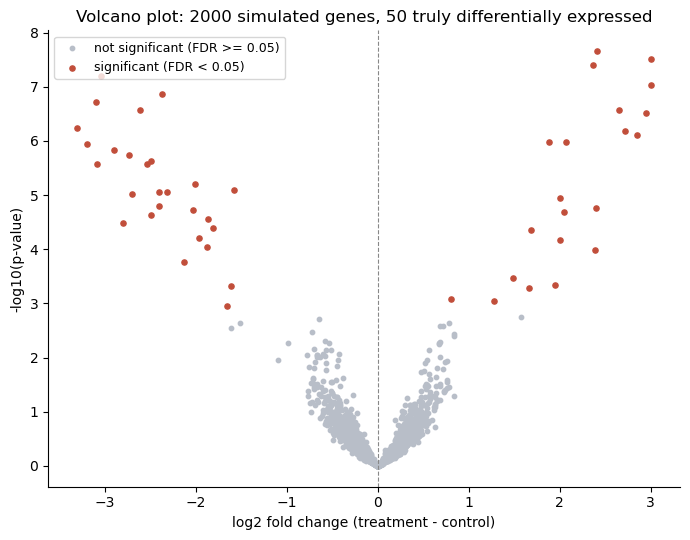

In [15]:
fig, ax = plt.subplots(figsize=(7, 5.5))
ax.scatter(obs_lfc[~sig_fdr], -np.log10(pvals[~sig_fdr]), s=10, color="#b8bec8", label="not significant (FDR >= 0.05)")
ax.scatter(obs_lfc[sig_fdr], -np.log10(pvals[sig_fdr]), s=14, color="#c14e3a", label="significant (FDR < 0.05)")
ax.set_xlabel("log2 fold change (treatment - control)")
ax.set_ylabel("-log10(p-value)")
ax.set_title("Volcano plot: 2000 simulated genes, 50 truly differentially expressed")
ax.legend(loc="upper left", fontsize=9)
ax.axvline(0, color="#888", linewidth=0.8, linestyle="--")
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
fig.tight_layout()
plt.show()

## Logarithms and exponential functions

In [16]:
import math

# log turns multiplication into addition
x, y = 3.0, 7.0
print("log(x) + log(y) =", math.log(x) + math.log(y))
print("log(x * y)       =", math.log(x * y))

# Worked example: p = 0.001 on the volcano plot's y-axis
p = 0.001
print("-log10(p) =", -math.log10(p))

# Practice problem 3: -log10(1e-6)
print("practice problem 3:", -math.log10(1e-6))

# Sigmoid function: squashes any real z into (0, 1)
def sigmoid(z):
    return 1 / (1 + math.exp(-z))

for z in [-5, -1, 0, 1, 5]:
    print(f"sigmoid({z}) =", sigmoid(z))


log(x) + log(y) = 3.044522437723423
log(x * y)       = 3.044522437723423
-log10(p) = 3.0
practice problem 3: 6.0
sigmoid(-5) = 0.0066928509242848554
sigmoid(-1) = 0.2689414213699951
sigmoid(0) = 0.5
sigmoid(1) = 0.7310585786300049
sigmoid(5) = 0.9933071490757153


Both the gradient-descent table and the probability calculations match the by-hand answers from the Day 1 page — the simulation's numbers won't be exactly 3.5 or exactly 2/3 (it's random), but with half a million rolls they should be very close.